# **Neural-Sentinel: Multi-Stage Intrusion Detection System for Layer-3 Network Security**

---



**1. Executive Summary**
This project focuses on the development of a Machine Learning-driven Intrusion Detection System (IDS) specifically designed to safeguard the Network Layer (Layer 3) and Transport Layer (Layer 4). Traditional firewalls rely on static, human-defined rules that often fail against "Zero-Day" attacks. This project utilizes an adaptive Random Forest Classifier to learn the statistical "fingerprints" of malicious traffic, allowing it to identify threats like DDoS, Port Scanning, and IP Spoofing in real-time.

**2. Technical Project Description**
The Problem Statement
As network traffic becomes more complex, manual signature-based detection becomes a bottleneck. The goal is to create an automated system that can analyze packet-flow features (like duration, protocol type, and byte-transfer rates) to distinguish between legitimate user activity and malicious intrusions.

Data Foundation: The NSL-KDD Dataset
The project utilizes the NSL-KDD dataset, which is an improved version of the classic KDD’99. It contains over 125,000 records of network traffic, each characterized by 41 features. These features are categorized into:

Intrinsic Features: Protocol (TCP/UDP/ICMP), Service (HTTP/FTP), and connection duration.

Content Features: Data size (src_bytes/dst_bytes) and flag statuses (SF, S0, REJ).

Traffic Features: Statistics within a 2-second window (e.g., connection counts to the same host).

Methodology & Architecture
The project follows a rigorous 5-stage pipeline:

Data Preprocessing: Handling categorical variables through Label Encoding and scaling numerical ranges using Standardization.

Exploratory Data Analysis (EDA): Identifying correlations between network errors (SYN errors) and specific attack labels like Neptune.

Feature Engineering: Identifying the most "suspicious" features using Feature Importance rankings.

The Classifier: Implementing a Random Forest Ensemble, which combines multiple decision trees to reduce variance and handle the non-linear nature of network logs.

Rigorous Evaluation: Testing the model against a dedicated test set containing novel attacks not present during the training phase to measure the system's "Generalization" capability.

**3. Key Project Objectives**
Real-time Anomaly Detection: Reducing the time between an attack's start and its detection.

High Recall: Minimizing "False Negatives"—ensuring no hacker slips through the cracks.

Scalability: Designing a model lightweight enough to be deployed on edge routers.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('/content/KDDTrain+.txt')

In [3]:
df.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [4]:
# 1. Define the 43 column names (as per the NSL-KDD documentation)
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land",
    "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

In [5]:
# 2. Load the training set
df = pd.read_csv('KDDTrain+.txt', header=None, names=columns)

In [6]:
# 3. Basic Exploration
print("--- Dataset Shape ---")
print(df.shape)
print("\n--- Class Distribution (Normal vs. Attack) ---")
print(df['label'].value_counts().head(10))

--- Dataset Shape ---
(125973, 43)

--- Class Distribution (Normal vs. Attack) ---
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64


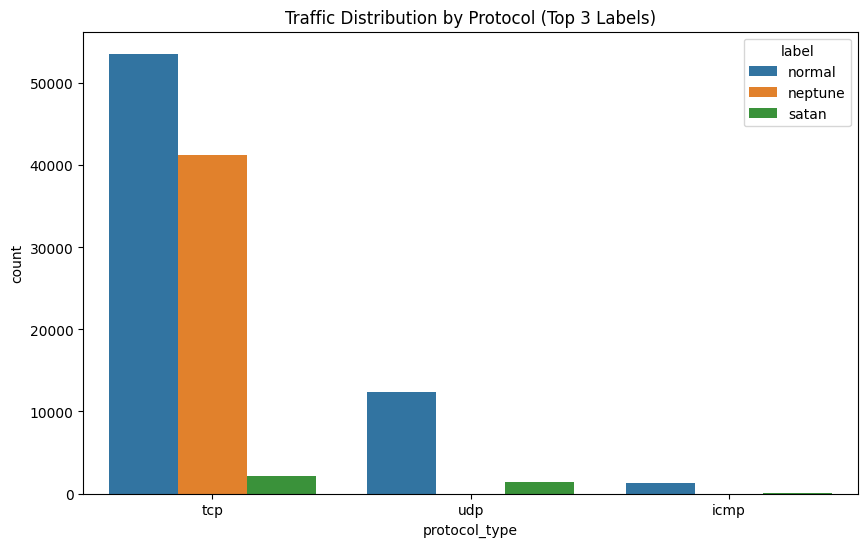

In [7]:
# 4. Visualization 1: Protocol Types
# This shows how many connections are TCP, UDP, or ICMP
plt.figure(figsize=(10, 6))
sns.countplot(x='protocol_type', hue='label', data=df[df['label'].isin(['normal', 'neptune', 'satan'])])
plt.title('Traffic Distribution by Protocol (Top 3 Labels)')
plt.show()

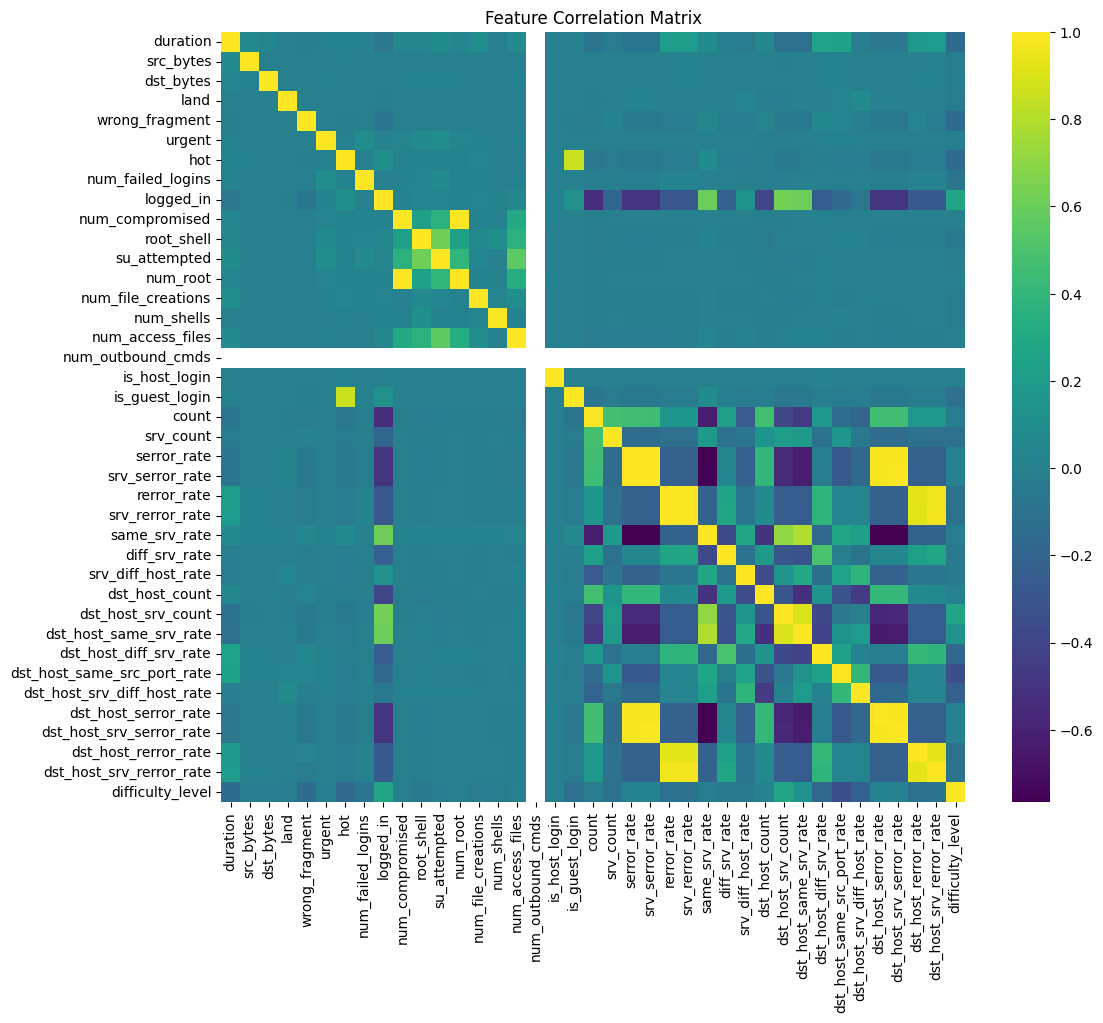

In [8]:
# 5. Visualization 2: Correlation Heatmap (Numerical Features only)
# This helps us see which network features move together
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='viridis')
plt.title('Feature Correlation Matrix')
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Separate Features and Label
X = df.drop(['label', 'difficulty_level'], axis=1)
y = df['label']

# 2. Encode categorical strings to numbers
# e.g., 'tcp' becomes 1, 'udp' becomes 2
le = LabelEncoder()
for col in ['protocol_type', 'service', 'flag']:
    X[col] = le.fit_transform(X[col])

# 3. Binary Classification: Convert all attack types to 'anomaly'
# This makes the problem simpler: Is it a hack or not?
y_binary = y.apply(lambda x: 0 if x == 'normal' else 1)

# 4. Scaling: Crucial for Network Data
# Prevents 'src_bytes' (large) from drowning out 'serror_rate' (small)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data is now normalized and ready for the Random Forest!")

Data is now normalized and ready for the Random Forest!


In [10]:
from sklearn.model_selection import train_test_split

# 1. Load the pre-split files from your folder
train_data = pd.read_csv('KDDTrain+.txt', header=None, names=columns)
test_data = pd.read_csv('KDDTest+.txt', header=None, names=columns)

# 2. Split the Training file into Train and Validation
# We do this so we can tune the model without touching the final test set
X_train_full = train_data.drop('label', axis=1)
y_train_full = train_data['label']

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# 3. Final Test set is kept aside
X_test = test_data.drop('label', axis=1)
y_test = test_data['label']

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Data
train_df = pd.read_csv('KDDTrain+.txt', header=None, names=columns)
test_df = pd.read_csv('KDDTest+.txt', header=None, names=columns)

# 2. Preprocessing Function (To keep it consistent for both sets)
def preprocess_kdd(df):
    # Drop the difficulty level and target
    X = df.drop(['label', 'difficulty_level'], axis=1)
    # Binary target: 0 for normal, 1 for any attack
    y = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

    # Label Encoding for categorical columns
    le = LabelEncoder()
    for col in ['protocol_type', 'service', 'flag']:
        X[col] = le.fit_transform(X[col])
    return X, y

X_train_full, y_train_full = preprocess_kdd(train_df)
X_test, y_test = preprocess_kdd(test_df)

# 3. Internal Validation Split (The "Class Test")
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# 4. Feature Scaling (Must fit on Train and transform others)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 5. Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Evaluation
val_preds = model.predict(X_val)
test_preds = model.predict(X_test)

print(f"Validation Accuracy: {accuracy_score(y_val, val_preds):.4f}")
print(f"Final Test Accuracy: {accuracy_score(y_test, test_preds):.4f}")

Validation Accuracy: 0.9987
Final Test Accuracy: 0.7751


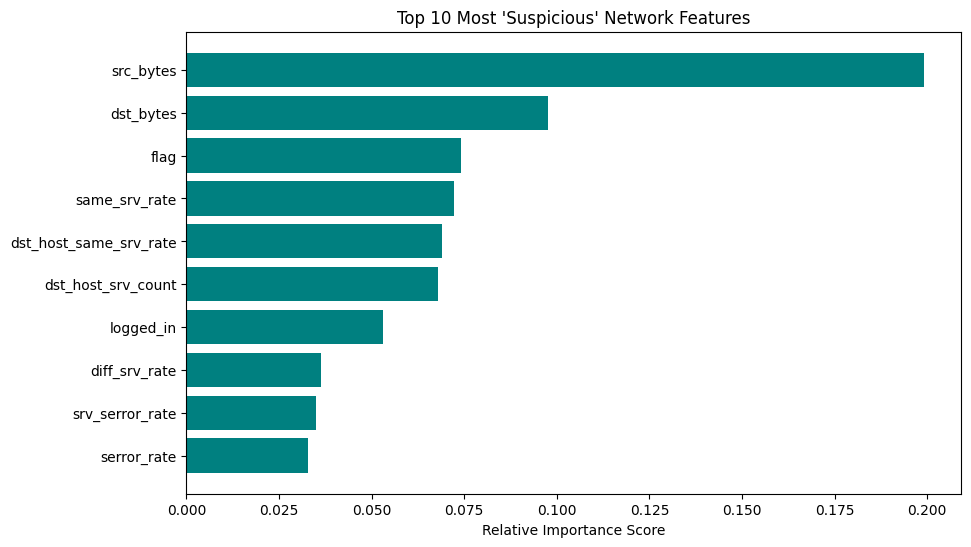

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get feature importance from the trained model
importances = model.feature_importances_
feature_names = X_train_full.columns
indices = np.argsort(importances)[-10:]  # Get top 10 features

# 2. Plotting
plt.figure(figsize=(10, 6))
plt.title("Top 10 Most 'Suspicious' Network Features")
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance Score')
plt.show()